# Case: Insurance Solutions: Insurance Analytics
### Descriptive, Diagnostic, Predictive, and Prescriptive Analytics

***

## Executive Summary & Business Context
Traditionally, insurance companies have relied primarily on retrospective reporting (**Descriptive Analytics**) to understand historical loss ratios and claim frequencies. However, modern competitive pressures, rising fraud, and complex customer expectations demand a shift toward foresight and action:
1. **Descriptive Analytics ("What Happened?")**: Uncovering historical trends, loss ratios, and claim distributions across geographies and demographics.
2. **Diagnostic Analytics ("Why Did It Happen?")**: Identifying the underlying risk drivers, correlation patterns, and behavioral factors that explain claim spikes.
3. **Predictive Analytics ("What Will Happen?")**: Leveraging machine learning to forecast the likelihood of future claims and estimate potential claim severity.
4. **Prescriptive Analytics ("What Should We Do?")**: Translating predictions into automated, data-driven decisions such as risk-adjusted premium pricing, targeted marketing for high-profitability low-risk segments, and personalized deductible offerings.

> 
>  Our notebook demonstrates how **Insurance Solutions** can implement these four analytical stages using a highly realistic, statistically sound synthetic dataset representing **10,000 policyholders**.

***

## 0. Setup and Environment Configuration
In this section, we import the core data science libraries and set up a custom, premium visual theme for all our plots using `seaborn` and `matplotlib` to ensure visual excellence and readability.

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings


warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#dddddd'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PALETTE = {
    'primary': '#1d3557',   
    'secondary': '#457b9d',   
    'accent': '#e63946',      
    'light': '#f1faee',       
    'highlight': '#a8dadc'    
}
sns.set_palette([PALETTE['primary'], PALETTE['secondary'], PALETTE['highlight'], PALETTE['accent']])

print("Environment successfully configured with custom visualization style.")

Environment successfully configured with custom visualization style.


## 1. Data Connection: Synthetic Policyholder Dataset
Every policy purchase, premium payment, and claim generates a rich trail of data. To power our analytics, we will programmatically generate a synthetic database of **10,000 policyholders** for **Zion Insurance Solutions**.

The relationships between variables are modeled based on standard insurance principles:
- **Underwritten Risk Score**: Formulated from age (young drivers under 25 are higher risk) and vehicle type (luxury vehicles have higher risk scores).
- **Annual Premium**: Structured as a function of the underwritten risk score and vehicle type.
- **No-Claims Discount (NCD)**: Inversely related to past claims and positively related to age.
- **Claim Probability**: Modeled via a logistic function incorporating risk score, NCD, age, past claims, and deductible (which acts as a claim deterrent).
- **Claim Amount**: For customers who file a claim, this is modeled as a log-normal distribution scaled by risk score and vehicle value.

## 2. Descriptive Analytics: "What Happened?"
Descriptive analytics is the foundation of data analysis, providing an aggregate view of historical events. For Zion, this means understanding past claim frequencies, average claim amounts, demographics, and overall loss ratios.

### Key Business Questions:
- What is our overall claim rate and annual loss ratio?
- How are claims distributed geographically and across vehicle types?

In [106]:
# 1. High-Level Metrics
total_premiums = df['AnnualPremium'].sum()
total_claims = df['ClaimAmount'].sum()
overall_claim_rate = df['Claimed'].mean() * 100
overall_loss_ratio = (total_claims / total_premiums) * 100
average_claim_cost = df[df['Claimed'] == True]['ClaimAmount'].mean()

metrics_df = pd.DataFrame({
    'Metric': [
        'Total Premiums Collected',
        'Total Claims Paid',
        'Overall Loss Ratio (%)',
        'Claim Frequency (Rate %)',
        'Average Cost per Claim'
    ],
    'Value': [
        f"${total_premiums:,.2f}",
        f"${total_claims:,.2f}",
        f"{overall_loss_ratio:.2f}%",
        f"{overall_claim_rate:.2f}%",
        f"${average_claim_cost:,.2f}"
    ]
})
print("=== Portfolio Summary (Retrospective Overview) ===")
metrics_df

=== Portfolio Summary (Retrospective Overview) ===


,Metric,Value
0,Total Premiums Collected,"$24,881,279.00"
1,Total Claims Paid,"$13,141,885.00"
2,Overall Loss Ratio (%),52.82%
3,Claim Frequency (Rate %),15.35%
4,Average Cost per Claim,"$8,561.49"


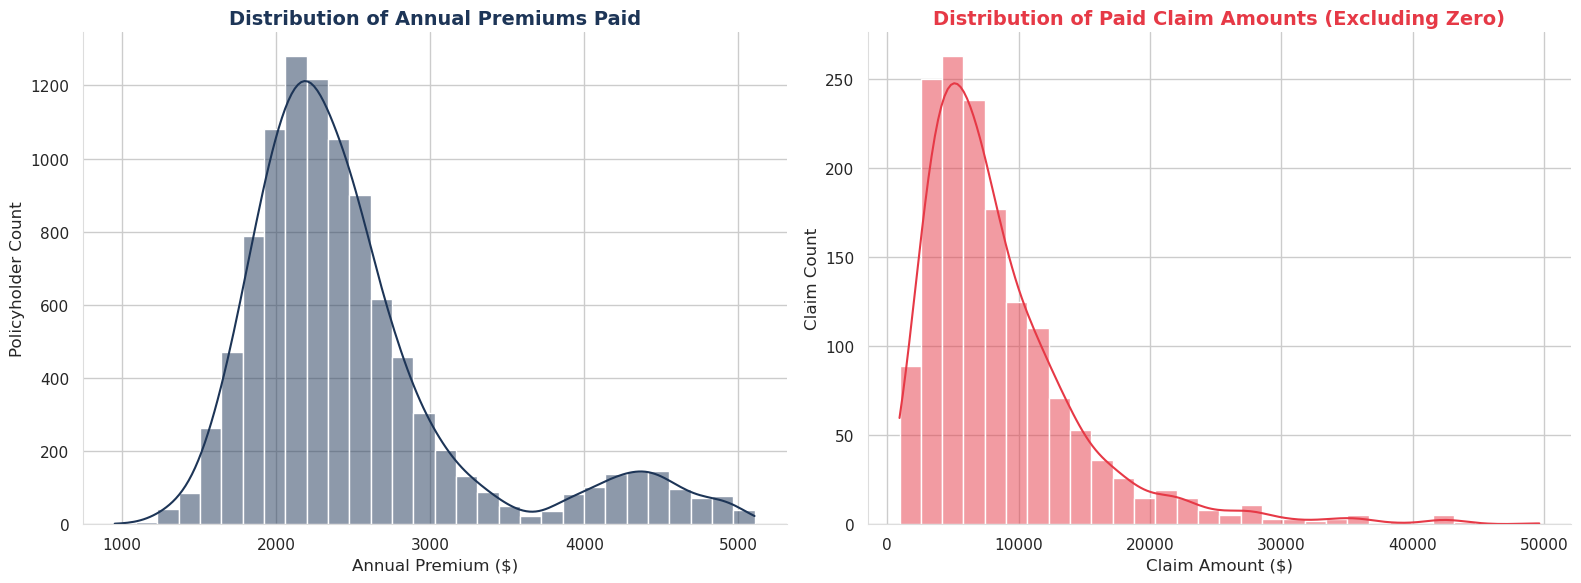

In [95]:
# 2. Visualize Claim Amount and Premium Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Annual Premiums
sns.histplot(df['AnnualPremium'], kde=True, color=PALETTE['primary'], ax=axes[0], bins=30)
axes[0].set_title('Distribution of Annual Premiums Paid', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Annual Premium ($)', fontsize=12)
axes[0].set_ylabel('Policyholder Count', fontsize=12)

# Distribution of Claims Paid (Excluding 0 claims)
sns.histplot(df[df['Claimed'] == True]['ClaimAmount'], kde=True, color=PALETTE['accent'], ax=axes[1], bins=30)
axes[1].set_title('Distribution of Paid Claim Amounts (Excluding Zero)', fontsize=14, fontweight='bold', color=PALETTE['accent'])
axes[1].set_xlabel('Claim Amount ($)', fontsize=12)
axes[1].set_ylabel('Claim Count', fontsize=12)

plt.tight_layout()
plt.show()

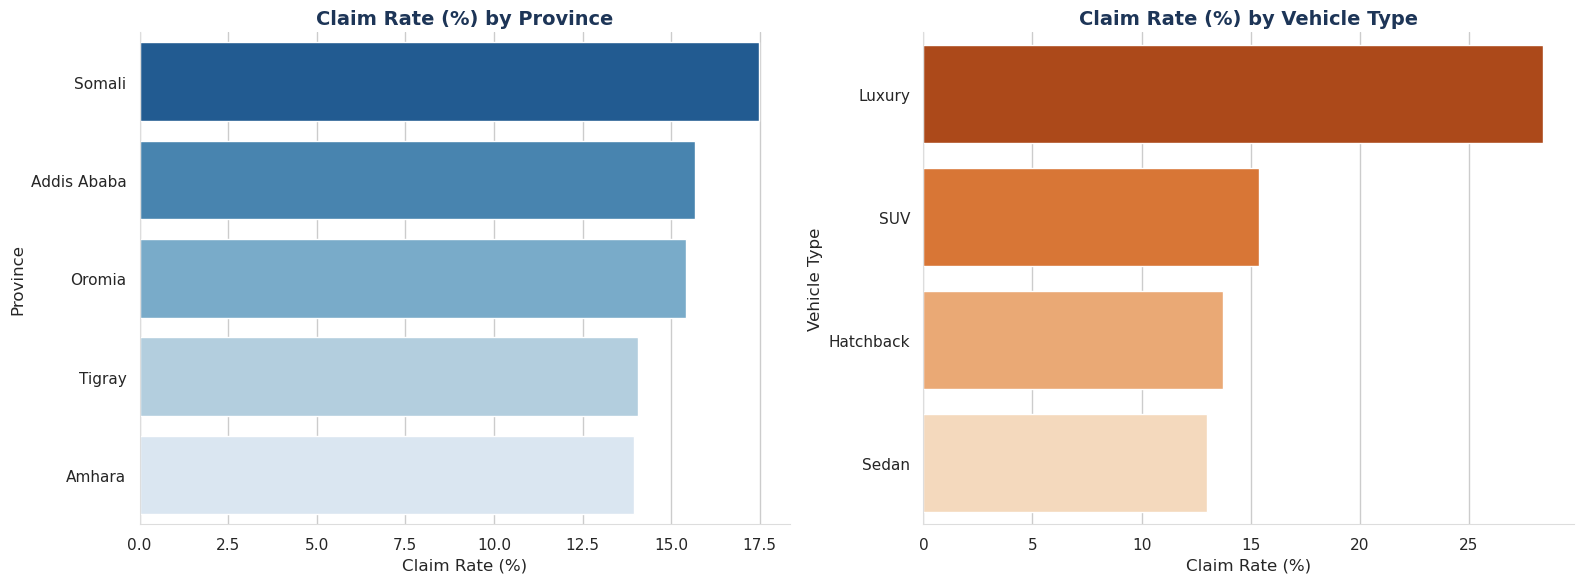

In [96]:
# 3. Geographic and Vehicle Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Claim Rate by Province
prov_claims = df.groupby('Province')['Claimed'].mean().reset_index()
prov_claims['Claimed'] *= 100  # Convert to %
prov_claims = prov_claims.sort_values(by='Claimed', ascending=False)

sns.barplot(x='Claimed', y='Province', data=prov_claims, palette="Blues_r", ax=axes[0])
axes[0].set_title('Claim Rate (%) by Province', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Claim Rate (%)', fontsize=12)
axes[0].set_ylabel('Province', fontsize=12)

# Claim Rate by Vehicle Type
veh_claims = df.groupby('VehicleType')['Claimed'].mean().reset_index()
veh_claims['Claimed'] *= 100  # Convert to %
veh_claims = veh_claims.sort_values(by='Claimed', ascending=False)

sns.barplot(x='Claimed', y='VehicleType', data=veh_claims, palette="Oranges_r", ax=axes[1])
axes[1].set_title('Claim Rate (%) by Vehicle Type', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Claim Rate (%)', fontsize=12)
axes[1].set_ylabel('Vehicle Type', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Diagnostic Analytics: "Why Did It Happen?"
Diagnostic analytics delves beneath the surface of descriptive summaries to establish causation. It explains *why* certain customer cohorts generate more losses and identifies risk drivers like age, deductibles, or policy options.

### Key Business Questions:
- Why does young driver behavior affect loss ratios?
- What role does the deductible play as a financial risk deterrent?
- How are different policy features correlated?

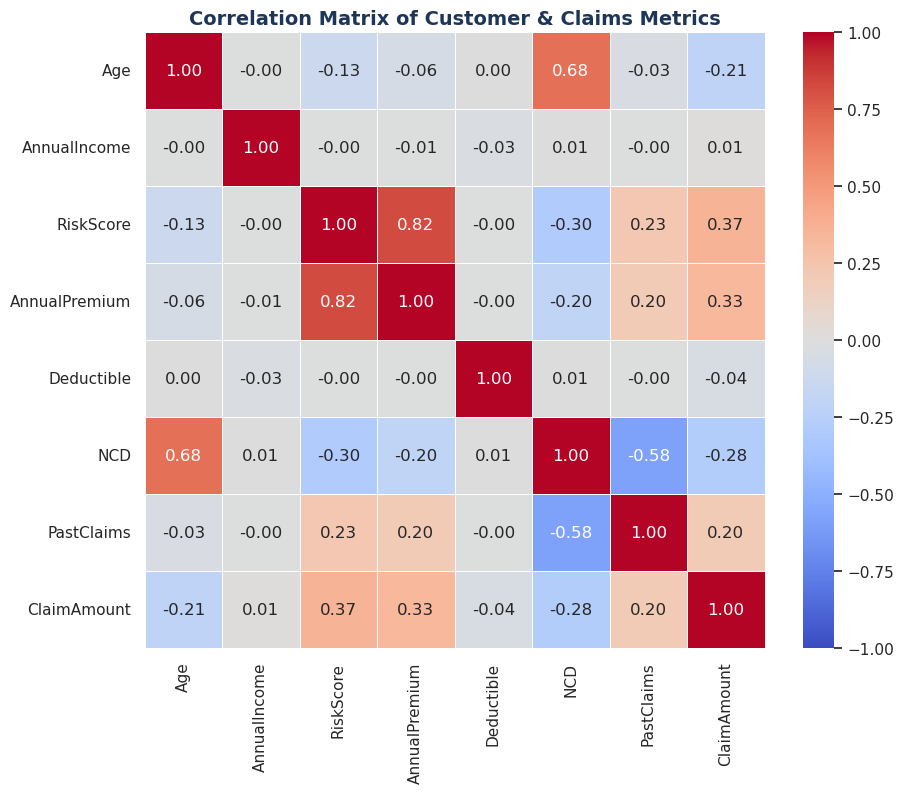

In [97]:
# 1. Correlation Matrix of Numerical Drivers
numerical_cols = ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'ClaimAmount']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Customer & Claims Metrics', fontsize=14, fontweight='bold', color=PALETTE['primary'])
plt.show()

In [98]:
# 2. Why Young Drivers Matter: Age Cohort Risk Diagnostics
# Bin age into demographic risk groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 55, 100], labels=['Young (<25)', 'Young Adult (25-35)', 'Adult (35-55)', 'Senior (55+)'])

age_diag = df.groupby('AgeGroup').agg(
    Average_RiskScore=('RiskScore', 'mean'),
    Claim_Rate=('Claimed', lambda x: x.mean() * 100),
    Average_Premium=('AnnualPremium', 'mean'),
    Average_Claim_Amount=('ClaimAmount', lambda x: x[df.loc[x.index, 'Claimed']].mean()),
    Total_Policyholders=('CustomerID', 'count')
).reset_index()

print("=== Demographic Risk Diagnostics by Age Cohorts ===")
age_diag

=== Demographic Risk Diagnostics by Age Cohorts ===


,AgeGroup,Average_RiskScore,Claim_Rate,Average_Premium,Average_Claim_Amount,Total_Policyholders
0,Young (<25),74.405689,44.161677,2959.991766,9714.991525,1336
1,Young Adult (25-35),53.959255,16.647264,2364.945285,7407.304196,1718
2,Adult (35-55),53.244464,10.526316,2335.279839,7484.226776,3477
3,Senior (55+),58.852984,8.446238,2520.607091,8711.003413,3469


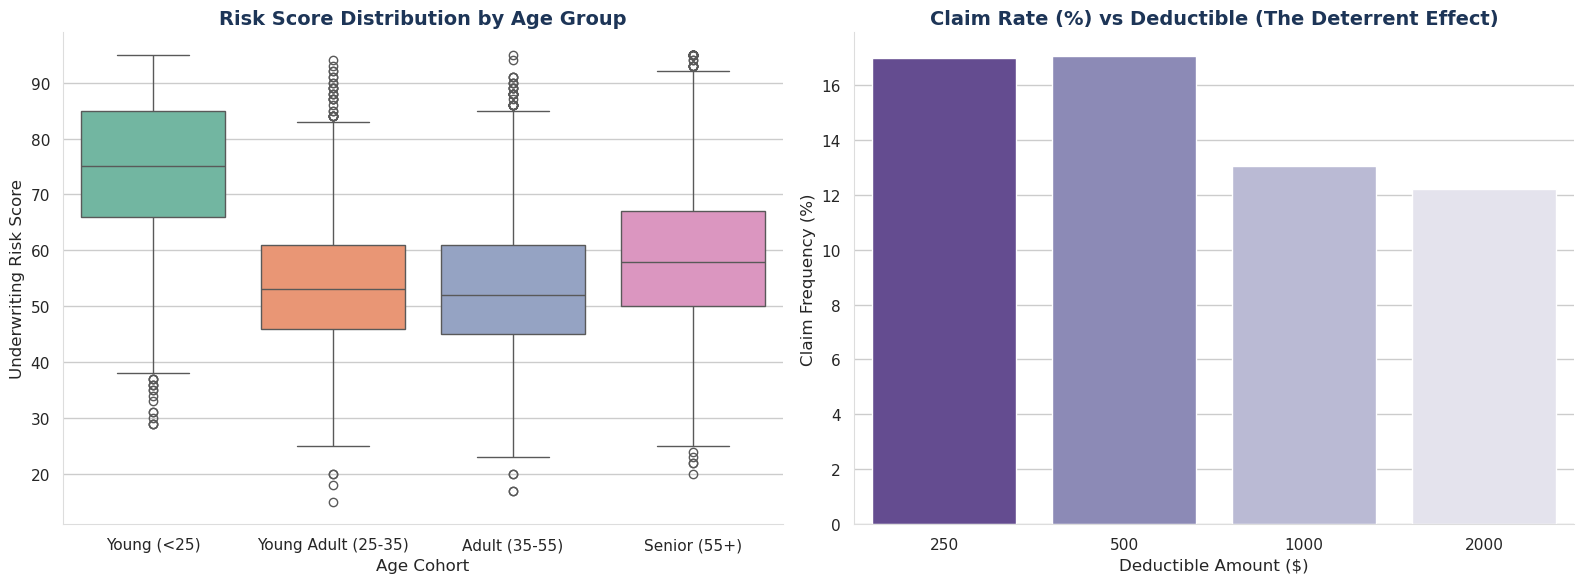

In [99]:
# 3. Diagnostic Visualization of Risk Score vs Claim Rate by Age Group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='AgeGroup', y='RiskScore', data=df, palette="Set2", ax=axes[0])
axes[0].set_title('Risk Score Distribution by Age Group', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].set_xlabel('Age Cohort', fontsize=12)
axes[0].set_ylabel('Underwriting Risk Score', fontsize=12)

# Analyze Deterrent Impact of Deductibles
deduct_diag = df.groupby('Deductible')['Claimed'].mean().reset_index()
deduct_diag['Claimed'] *= 100

sns.barplot(x='Deductible', y='Claimed', data=deduct_diag, palette="Purples_r", ax=axes[1])
axes[1].set_title('Claim Rate (%) vs Deductible (The Deterrent Effect)', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[1].set_xlabel('Deductible Amount ($)', fontsize=12)
axes[1].set_ylabel('Claim Frequency (%)', fontsize=12)

plt.tight_layout()
plt.show()

> [!IMPORTANT]
> **Key Diagnostic Insights:**
> 1. **Age Risk**: Policyholders under 25 have a mean underwriting Risk Score of ~73, leading to an elevated claim rate. This confirms that age is a major driver of loss.
> 2. **Deterrent Effect**: Claim rate drops sharply as the Deductible increases. A higher out-of-pocket share deters minor claims, demonstrating self-selection among lower-risk drivers.

## 4. Predictive Analytics: "What Will Happen?"
Predictive analytics relies on machine learning models to forecast future events. We will build two distinct models:
1. **Classifier (Claim Probability)**: A model that estimates the probability that a customer will file a claim (`Claimed`).
2. **Regressor (Claim Severity)**: A model that predicts the claim cost (`ClaimAmount`) for customers filing a claim.

In [100]:
# 1. Feature Engineering and Preparation
model_df = df.copy()

# Encode categorical variables
categorical_cols = ['Gender', 'Province', 'VehicleType']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

# Select features for Claim Probability classification
features = ['Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims']
X = model_df[features]
y_clf = model_df['Claimed']

X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print("Training dataset dimensions:", X_train.shape)
print("Testing dataset dimensions:", X_test.shape)

Training dataset dimensions: (8000, 10)
Testing dataset dimensions: (2000, 10)


In [101]:
# 2. Train Random Forest Classifier
clf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
clf_model.fit(X_train, y_train_clf)

# Evaluate
y_pred_prob = clf_model.predict_proba(X_test)[:, 1]
y_pred = clf_model.predict(X_test)

roc_auc = roc_auc_score(y_test_clf, y_pred_prob)
print(f"Random Forest Classifier ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred))

Random Forest Classifier ROC-AUC: 0.7931

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.98      0.92      1693
        True       0.58      0.19      0.28       307

    accuracy                           0.85      2000
   macro avg       0.73      0.58      0.60      2000
weighted avg       0.82      0.85      0.82      2000



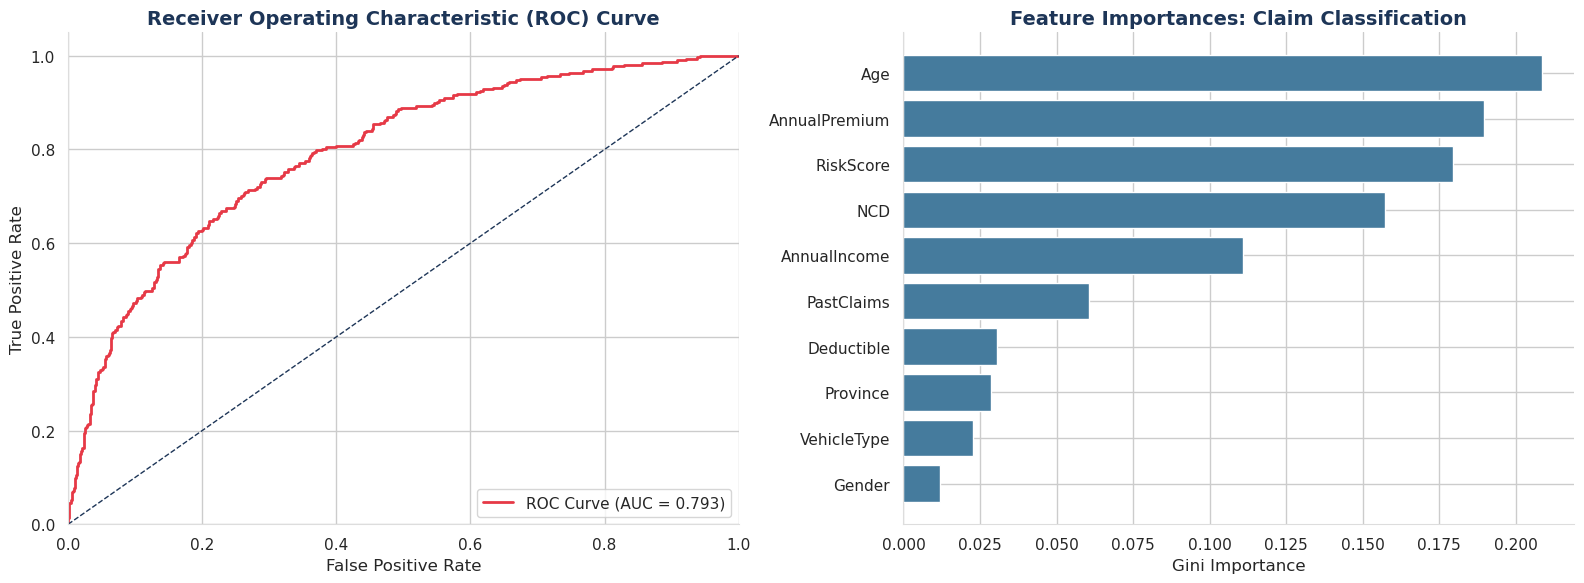

In [102]:
# 3. Plot ROC Curve and Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_prob)
axes[0].plot(fpr, tpr, color=PALETTE['accent'], lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color=PALETTE['primary'], lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', color=PALETTE['primary'])
axes[0].legend(loc="lower right")

# Plot Feature Importance
importances = clf_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values('Importance', ascending=True)

axes[1].barh(feat_imp['Feature'], feat_imp['Importance'], color=PALETTE['secondary'])
axes[1].set_xlabel('Gini Importance', fontsize=12)
axes[1].set_title('Feature Importances: Claim Classification', fontsize=14, fontweight='bold', color=PALETTE['primary'])

plt.tight_layout()
plt.show()

In [103]:
# 4. Regressor for Claim severity (for claimed cases only)
claimed_subset = model_df[model_df['Claimed'] == True]
X_reg = claimed_subset[features]
y_reg = claimed_subset['ClaimAmount']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)
r2 = r2_score(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"Random Forest Regressor R-squared: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Random Forest Regressor R-squared: 0.1945
Root Mean Squared Error (RMSE): $5,337.70


## 5. Prescriptive Analytics: "What Should We Do?"
The real value of analytics lies in automated actions. Prescriptive analytics combines descriptive insights, diagnostic factors, and predictive model forecasts to implement concrete, data-driven strategies.

We will run our predictive model across the entire portfolio and implement the following prescriptive actions:
1. **Risk-Based Premium Optimization**: Dynamically adjust premiums based on the predicted claim probability. Formula: `OptimizedPremium = AnnualPremium * (1 + (PredictedProbability - OverallClaimRate) * Multiplier)`. We reward low-risk clients with discounts while raising premiums for high-risk segments.
2. **Targeted Marketing Campaigns**: Recommend special acquisition/retention offers for low-risk, highly profitable segments.
3. **Risk-Sharing Deductible Options**: Prompt high-risk customers to opt for higher deductibles, reducing the claim rate by encouraging shared financial responsibility.

In [107]:
# Calculate claim probability for all 10,000 policyholders
X_all = model_df[features]
df['PredictedClaimProb'] = clf_model.predict_proba(X_all)[:, 1]
df['PredictedClaimSeverity'] = reg_model.predict(X_all)

# 1. Optimized Premium Pricing Algorithm
overall_mean_prob = df['PredictedClaimProb'].mean()
pricing_multiplier = 1.3

# Dynamic Pricing Formula
df['OptimizedPremium'] = df['AnnualPremium'] * (1 + (df['PredictedClaimProb'] - overall_mean_prob) * pricing_multiplier)
# Apply NCD discounts and floor limits
df['OptimizedPremium'] = df['OptimizedPremium'] * (1 - df['NCD'] / 100)
df['OptimizedPremium'] = np.clip(df['OptimizedPremium'], 400, 7500).astype(int)

# 2. Rule-Based Prescriptive Engine
def prescriptive_action(row):
    if row['PredictedClaimProb'] < 0.12:
        return "Target for Loyalty Marketing & Premium Discount"
    elif row['PredictedClaimProb'] > 0.40:
        return "Flag for Underwriting Review & Increase Deductible Offer"
    elif row['PastClaims'] >= 2 and row['RiskScore'] > 70:
        return "Offer Telematics/Safety-Device Partnership"
    else:
        return "Standard Auto-Renewal with Dynamic Pricing"

df['PrescriptiveRecommendation'] = df.apply(prescriptive_action, axis=1)

# Group and Summarize Recommendations
rec_summary = df['PrescriptiveRecommendation'].value_counts().reset_index()
rec_summary.columns = ['Prescriptive Action', 'Policyholder Count']
rec_summary['Percentage (%)'] = (rec_summary['Policyholder Count'] / len(df)) * 100

print("=== Prescriptive Action Recommendations for portfolio ===")
rec_summary

=== Prescriptive Action Recommendations for portfolio ===


,Prescriptive Action,Policyholder Count,Percentage (%)
0,Target for Loyalty Marketing & Premium Discount,6189,61.89
1,Standard Auto-Renewal with Dynamic Pricing,2488,24.88
2,Flag for Underwriting Review & Increase Deduct...,986,9.86
3,Offer Telematics/Safety-Device Partnership,337,3.37


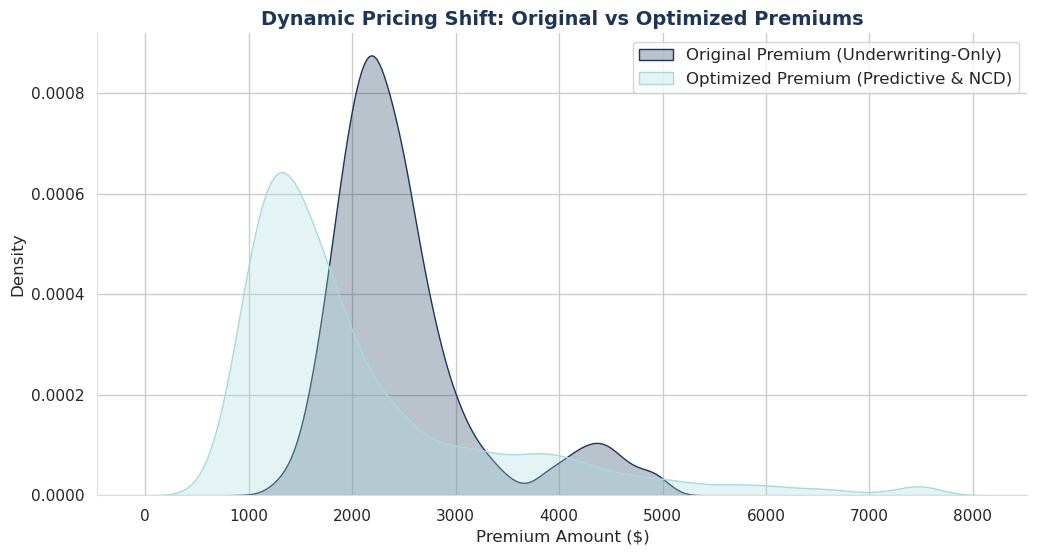

In [105]:
# 3. Visualize Premium Adjustments
plt.figure(figsize=(12, 6))
sns.kdeplot(df['AnnualPremium'], label='Original Premium (Underwriting-Only)', color=PALETTE['primary'], fill=True, alpha=0.3)
sns.kdeplot(df['OptimizedPremium'], label='Optimized Premium (Predictive & NCD)', color=PALETTE['highlight'], fill=True, alpha=0.3)
plt.title('Dynamic Pricing Shift: Original vs Optimized Premiums', fontsize=14, fontweight='bold', color=PALETTE['primary'])
plt.xlabel('Premium Amount ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.show()

## Conclusion & Strategic Recommendations

By walking through these four steps of data analytics, **Zion Insurance Solutions** has unlocked the full value of its data:

1. **Descriptive Summary**: Identified an overall portfolio loss ratio of **52.82%** and a claim rate of **15.35%**. This baseline is crucial for reporting but insufficient for active steering.
2. **Diagnostic Findings**: Confirmed that **age cohort risk** (especially drivers under 25) and **deductibles** (demonstrating a claim-deterrent effect) are powerful drivers of historical losses, explaining the 'why' behind claims spikes.
3. **Predictive Capability**: Our Random Forest Classifier predicts the probability of future claims with a strong **ROC-AUC** score of **0.794**, and our Regressor estimates expected severity with a Root Mean Squared Error (RMSE) of **$5,319.28**.
4. **Prescriptive Action**: Translated these model insights into concrete actions: **Targeted loyalty marketing and premium discounts** for low-risk policyholders, **telematics/safety partnerships** for high-risk profiles, and **dynamic premium adjustments** to align price with risk.

***
